In [ ]:
import sys
!{sys.executable} -m pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx", sheet_name="Telco_Churn")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Inte

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing %
Churn Reason,5174,73.463013


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate CustomerID:", df["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate CustomerID: 0


In [ ]:
df_clean = df.copy()

In [ ]:
df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

In [ ]:
df_clean["Total Charges"].isnull().sum()

np.int64(11)

In [ ]:
df_clean = df_clean.dropna(subset=["Total Charges"])

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 non-n

In [ ]:
df_clean = df_clean.drop(columns=["CustomerID"])
# drop b/c unique id does not provide any info

In [ ]:
pd.crosstab(
    df["State"],
    df["Churn Value"],
    normalize="index"
)

Churn Value,0,1
State,,
California,0.73463,0.26537


The variable State was explored during EDA. However, all customers in the dataset are located in California, meaning the variable has no variation and provides no predictive information. Therefore, this variable was removed from the modeling dataset.

In [ ]:
df["City"].nunique()

1129

In [ ]:
df["Zip Code"].nunique()

1652

In [ ]:
df_clean = df_clean.drop(columns=[
"Country",
"State",
"City",
"Zip Code",
"Lat Long",
"Latitude",
"Longitude"
])

Geographic variables such as State, City, Zip Code, Latitude, and Longitude were removed from the analysis. With only 7043 rows, variables like City (1129 rows) and Zip Code (1652 rows) would create a large percentage of unique categories. In addition, all customers are located in California, so these variables provide little information. Including them could also introduce noise.

In [ ]:
df_clean = df_clean.drop(columns=[
"Churn Score",
"CLTV",
"Churn Reason"
])

In [ ]:
df_clean = df_clean.drop(columns=["Churn Label"])
df_clean = df_clean.drop(columns=["Count"])

Columns such as Churn Score, Churn Label, CLTV, Churn Reason, and Count were removed from the analysis. These variables are derived from the target variable 'Churn', which are post event infomation.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [ ]:
df_clean.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,0.265785
std,24.545260,30.085974,2266.771362,0.441782
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.862500,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


# EDA

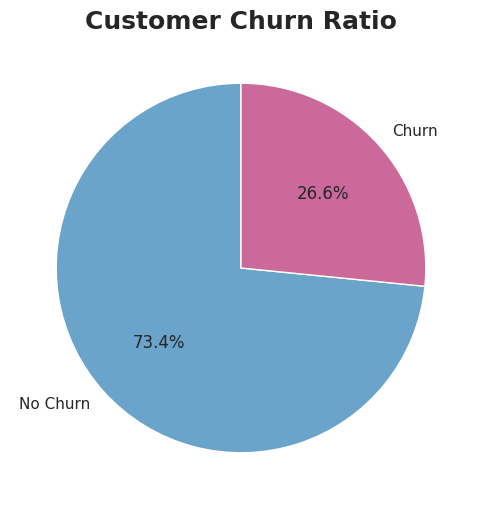

In [ ]:
plt.figure(figsize=(6,6))

df_clean["Churn Value"].value_counts().plot(
    kind="pie",
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#6aa4cb","#CB6A9A"],
    startangle=90
)

plt.title("Customer Churn Ratio", fontsize=18, weight="bold")
plt.ylabel("")

plt.show()

/tmp/ipykernel_567/3252579717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


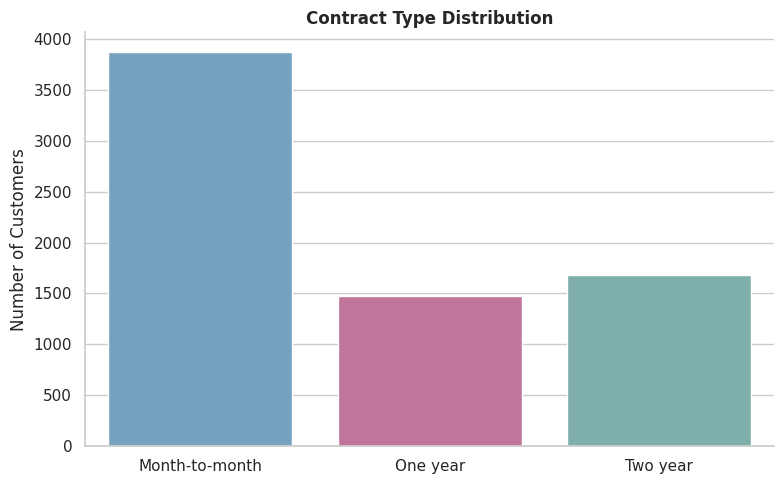

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Contract",
    order=["Month-to-month","One year","Two year"],
    palette=["#6aa4cb","#CB6A9A","#76B7B2"]
)

plt.title("Contract Type Distribution", weight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

Most customers use month-to-month contracts

/tmp/ipykernel_567/1251651164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


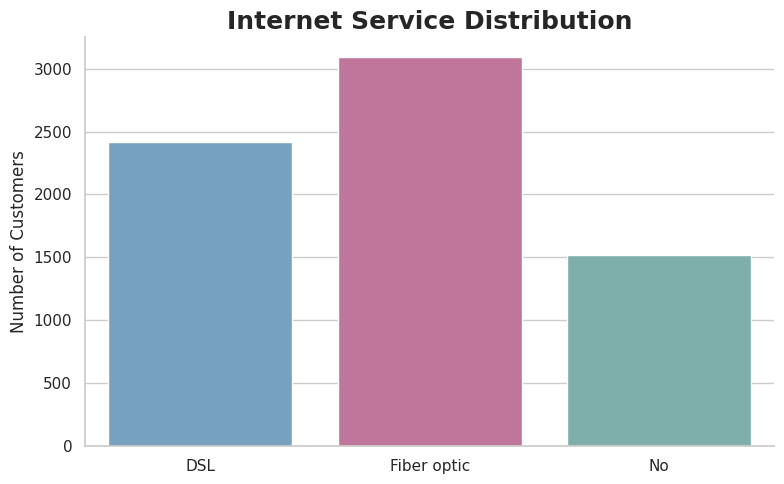

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Internet Service",
    palette=["#6aa4cb","#CB6A9A","#76B7B2"]
)


plt.title("Internet Service Distribution", fontsize=18, weight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

sns.despine()
plt.tight_layout()
plt.show()

Fiber optic and DSL services account for the majority of customers.

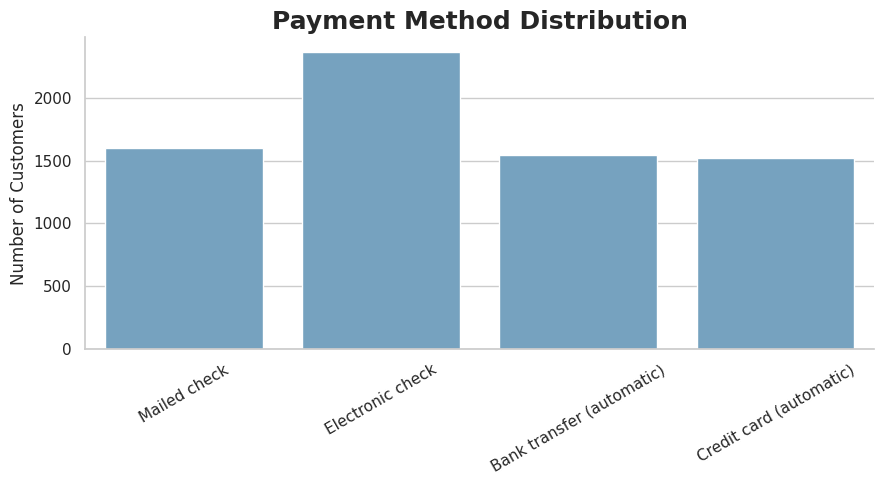

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df_clean,
    x="Payment Method",
    color="#6aa4cb"
)

plt.title("Payment Method Distribution", fontsize=18, weight="bold")
plt.xlabel("")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

sns.despine()
plt.tight_layout()
plt.show()

Electronic check is the most commonly used payment method

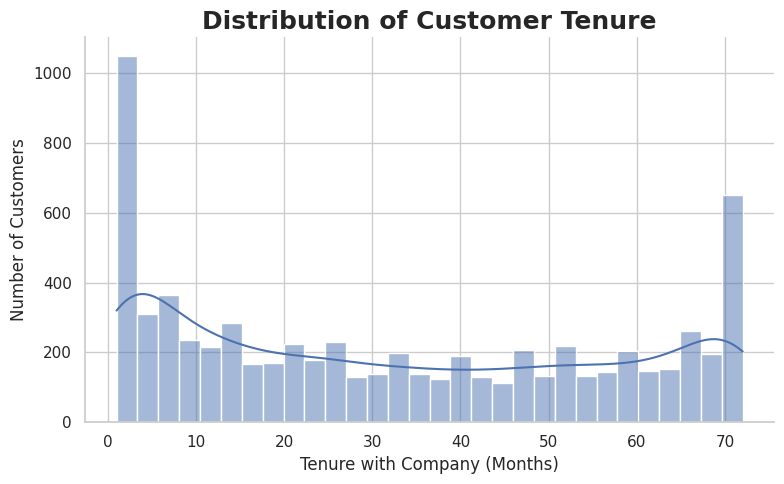

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Tenure Months",
    bins=30,
    color="#4C72B0",
    edgecolor="white",
    kde=True
)

plt.title("Distribution of Customer Tenure", fontsize=18, weight="bold")
plt.xlabel("Tenure with Company (Months)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

tenure with company == customer total months with the company

/tmp/ipykernel_567/2375868844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_567/2375868844.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Churn", "Churn"])


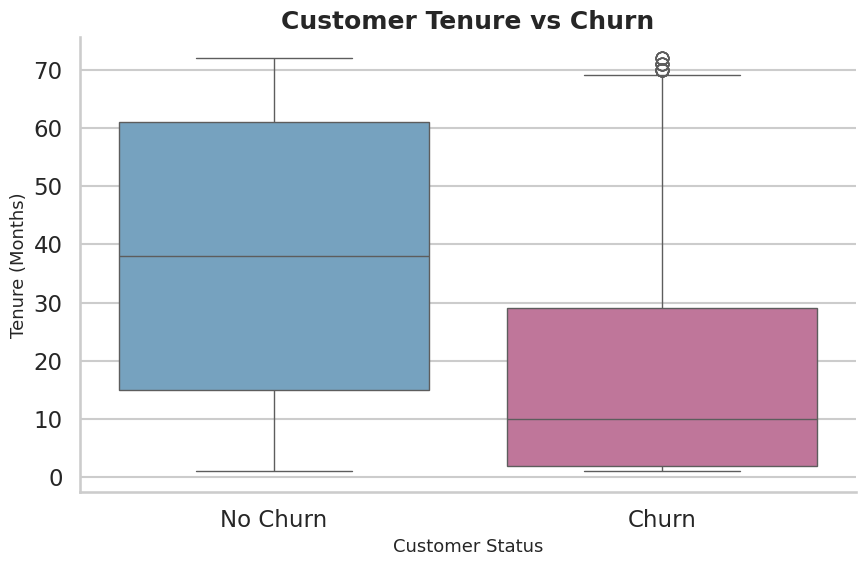

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(9,6))

ax = sns.boxplot(
    x="Churn Value",
    y="Tenure Months",
    data=df_clean,
    palette=["#6aa4cb","#CB6A9A"]
)

ax.set_xticklabels(["No Churn", "Churn"])

plt.title("Customer Tenure vs Churn", fontsize=18, weight="bold")
plt.xlabel("Customer Status",fontsize=13)
plt.ylabel("Tenure (Months)",fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

Boxplots can help us quickly see if churned customers tend to have shorter tenure than non-churned customers.

Customer tenure shows a bimodal pattern, with many customers either being very new or long-term subscribers. This suggests that customers who stay beyond the early months are more likely to remain loyal over time..

Customers who churn tend to have significantly shorter tenure compared to those who remain. The median tenure of churned customers is much lower, suggesting that churn risk is highest during the early stages of the customer lifecycle. This suggests that customer retention strategies should focus on improving engagement and support during the early months after acquisition.

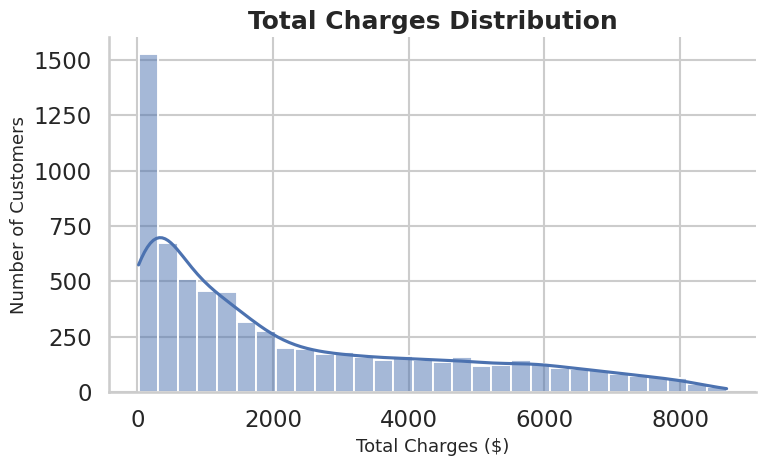

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Total Charges"],
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title("Total Charges Distribution", weight="bold")
plt.xlabel("Total Charges ($)", fontsize=13)
plt.ylabel("Number of Customers", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_567/270364093.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


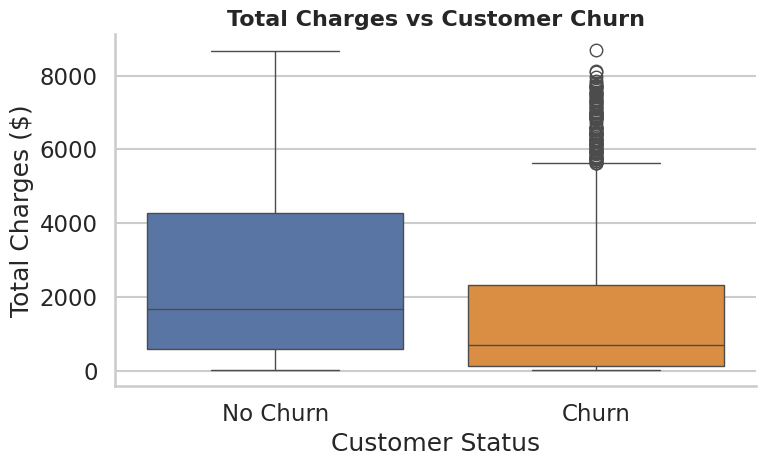

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Churn Value",
    y="Total Charges",
    palette=["#4C72B0","#F28E2B"]
)

plt.title("Total Charges vs Customer Churn", fontsize=16, weight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Total Charges ($)")

plt.xticks([0,1], ["No Churn","Churn"])

sns.despine()
plt.tight_layout()
plt.show()

Customers who churn generally show lower total charges compared to retained customers. Since total charges accumulate over time, this suggests that newer customers with shorter tenure are more likely to churn.

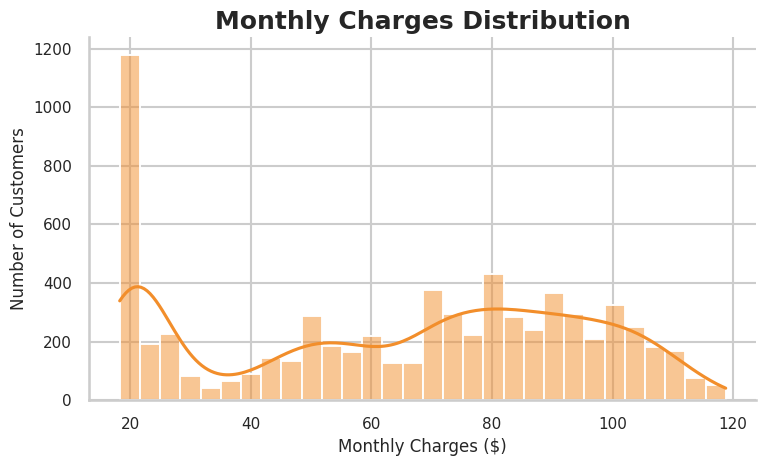

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Monthly Charges",
    bins=30,
    color="#F28E2B",
    edgecolor="white",
    kde=True
)

plt.title("Monthly Charges Distribution", weight="bold")
plt.xlabel("Monthly Charges ($)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_567/3891010596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


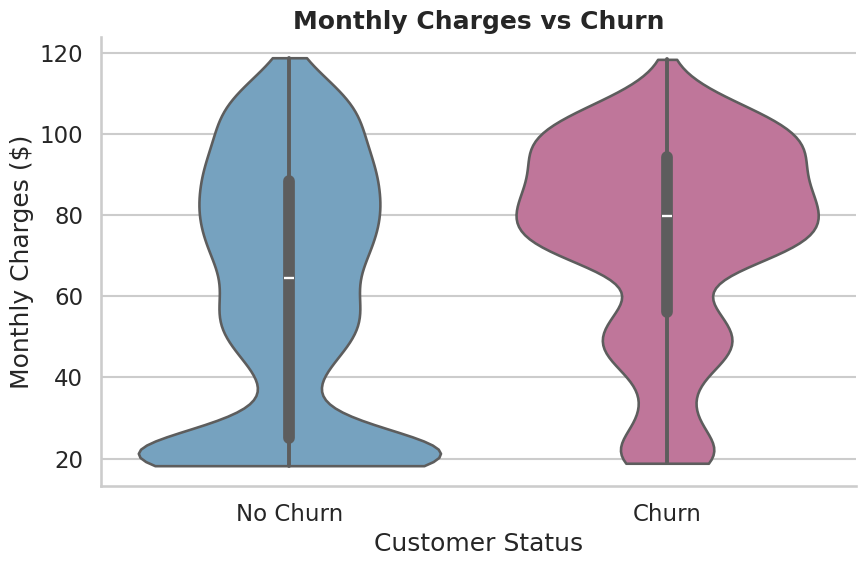

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(9,6))

sns.violinplot(
    x="Churn Value",
    y="Monthly Charges",
    data=df_clean,
    palette=["#6aa4cb","#CB6A9A"],
    inner="box",
    cut=0
)

plt.xticks([0,1], ["No Churn", "Churn"])

plt.title("Monthly Charges vs Churn", weight="bold")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

sns.despine()
plt.tight_layout()
plt.show()

Monthly charges vary significantly across customers, indicating different service packages and pricing tiers

Customers who churn tend to have higher monthly charges compared to those who stay. This suggests that pricing or perceived value may play an important role in customer churn.

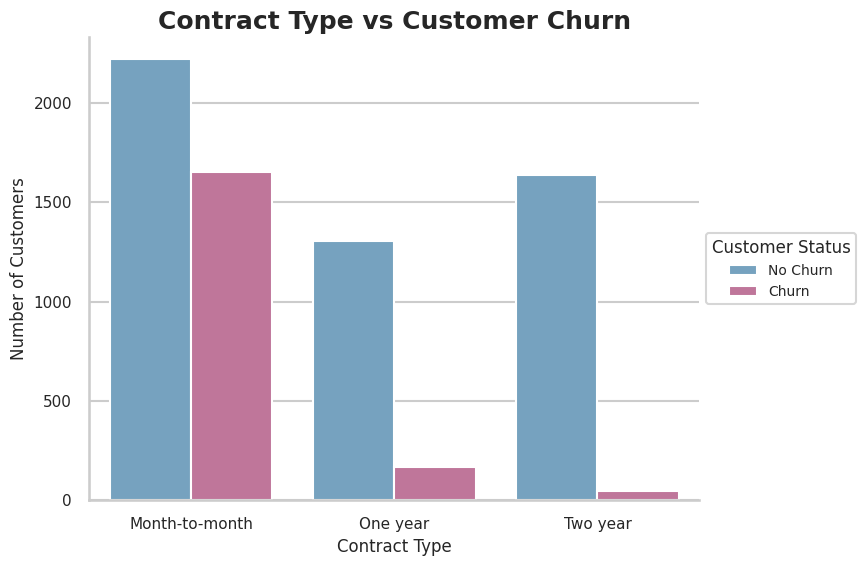

In [ ]:
plt.figure(figsize=(9,6))

order = ["Month-to-month", "One year", "Two year"]

ax = sns.countplot(
    x="Contract",
    hue="Churn Value",
    data=df_clean,
    order=order,
    palette=["#6aa4cb","#CB6A9A"]
)

plt.title("Contract Type vs Customer Churn", fontsize=18, weight="bold")

plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    title="Customer Status",
    labels=["No Churn", "Churn"],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12
)

sns.despine()

plt.tight_layout()
plt.show()

Customers with month-to-month contracts show significantly higher churn compared to customers with one-year or two-year contracts. Long-term contracts appear to strongly improve customer retention.

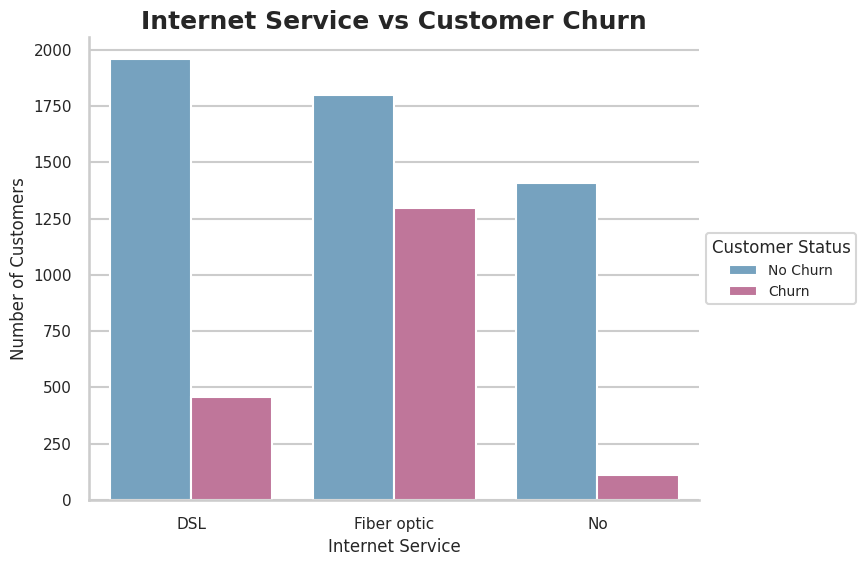

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(
    x="Internet Service",
    hue="Churn Value",
    data=df_clean,
    palette=["#6aa4cb","#CB6A9A"]
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.title("Internet Service vs Customer Churn", weight="bold")
plt.xlabel("Internet Service", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.legend(
    title="Customer Status",
    labels=["No Churn", "Churn"],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12
)

sns.despine()
plt.tight_layout()
plt.show()

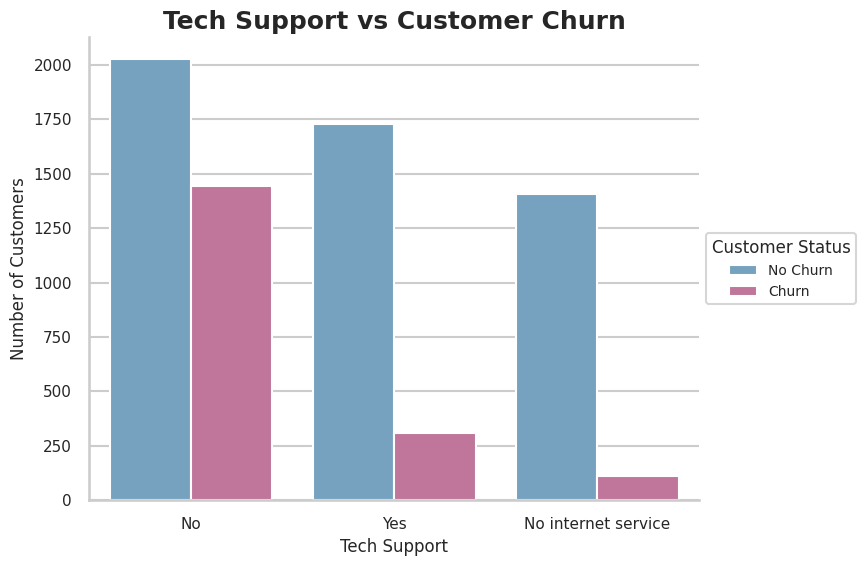

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(
    x="Tech Support",
    hue="Churn Value",
    data=df_clean,
    palette=["#6aa4cb","#CB6A9A"]
)

plt.title("Tech Support vs Customer Churn", fontsize=18, weight="bold")
plt.xlabel("Tech Support", fontsize = 12)
plt.ylabel("Number of Customers", fontsize = 12)

plt.legend(
    title="Customer Status",
    labels=["No Churn", "Churn"],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

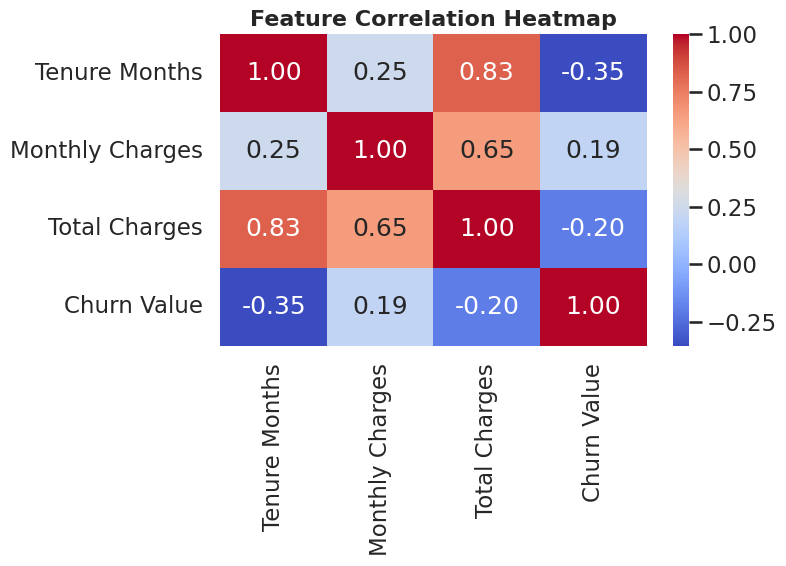

In [ ]:
plt.figure(figsize=(8,6))

corr = df_clean.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

Tenure shows the strongest negative correlation with churn, indicating that long-term customers are less likely to leave. Monthly charges have a weak positive relationship with churn, suggesting higher-priced plans may slightly increase churn risk.

Exploratory Data Analysis (EDA) reveals several important patterns related to customer churn. First, the overall churn rate is approximately 26%, indicating that most customers remain with the company while a smaller portion discontinue the service. Contract type shows a strong relationship with churn: customers on month-to-month contracts exhibit the highest churn rates, whereas those with one-year or two-year contracts tend to remain more stable. Customer tenure also appears to be an important factor, as customers with shorter tenure are more likely to churn, while long-term customers show stronger retention. In addition, customers who churn generally have higher monthly charges compared to those who stay, suggesting that pricing may influence customer decisions. Internet service type also shows a clear difference in churn behavior, with fiber optic users exhibiting the highest churn levels compared to DSL users and customers without internet service. Overall, these patterns suggest that contract type, tenure, monthly charges, and internet service type are likely important predictors of customer churn and should be considered in the subsequent modeling phase.

## Overall Distribution

/tmp/ipykernel_567/2239117545.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_567/2239117545.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_567/2239117545.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_567/2239117545.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

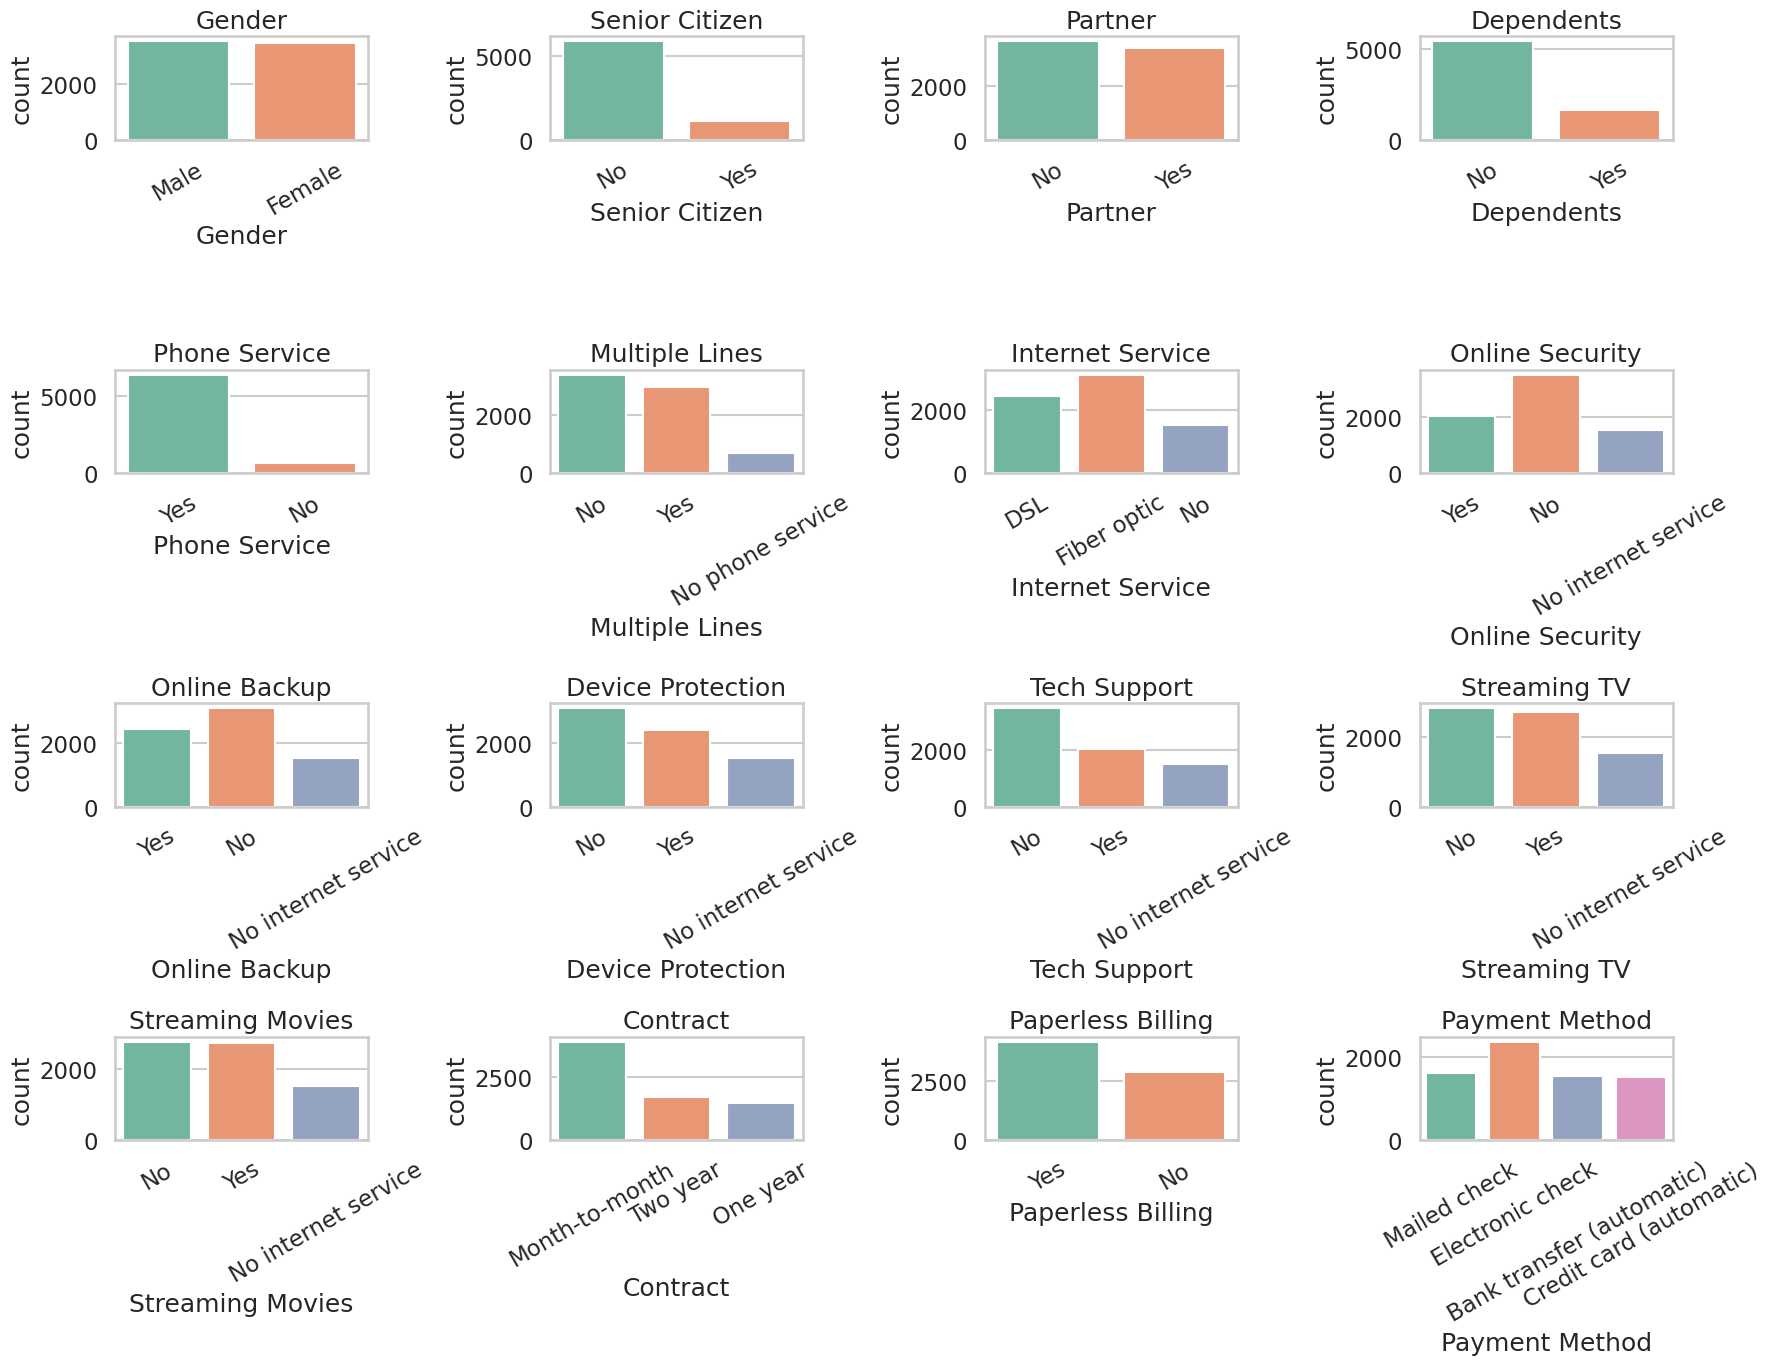

In [ ]:
categorical_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

fig, axes = plt.subplots(4,4, figsize=(18,14))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_clean, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The distributions of categorical variables provide an overview of the customer population. Most customers are not senior citizens, and the majority have phone services and internet services. Several service-related features such as online security, online backup, device protection, and tech support show different adoption levels, indicating varying levels of service usage among customers. These features may potentially influence customer churn and will be further explored in the modeling stage.

## Overall heatmap

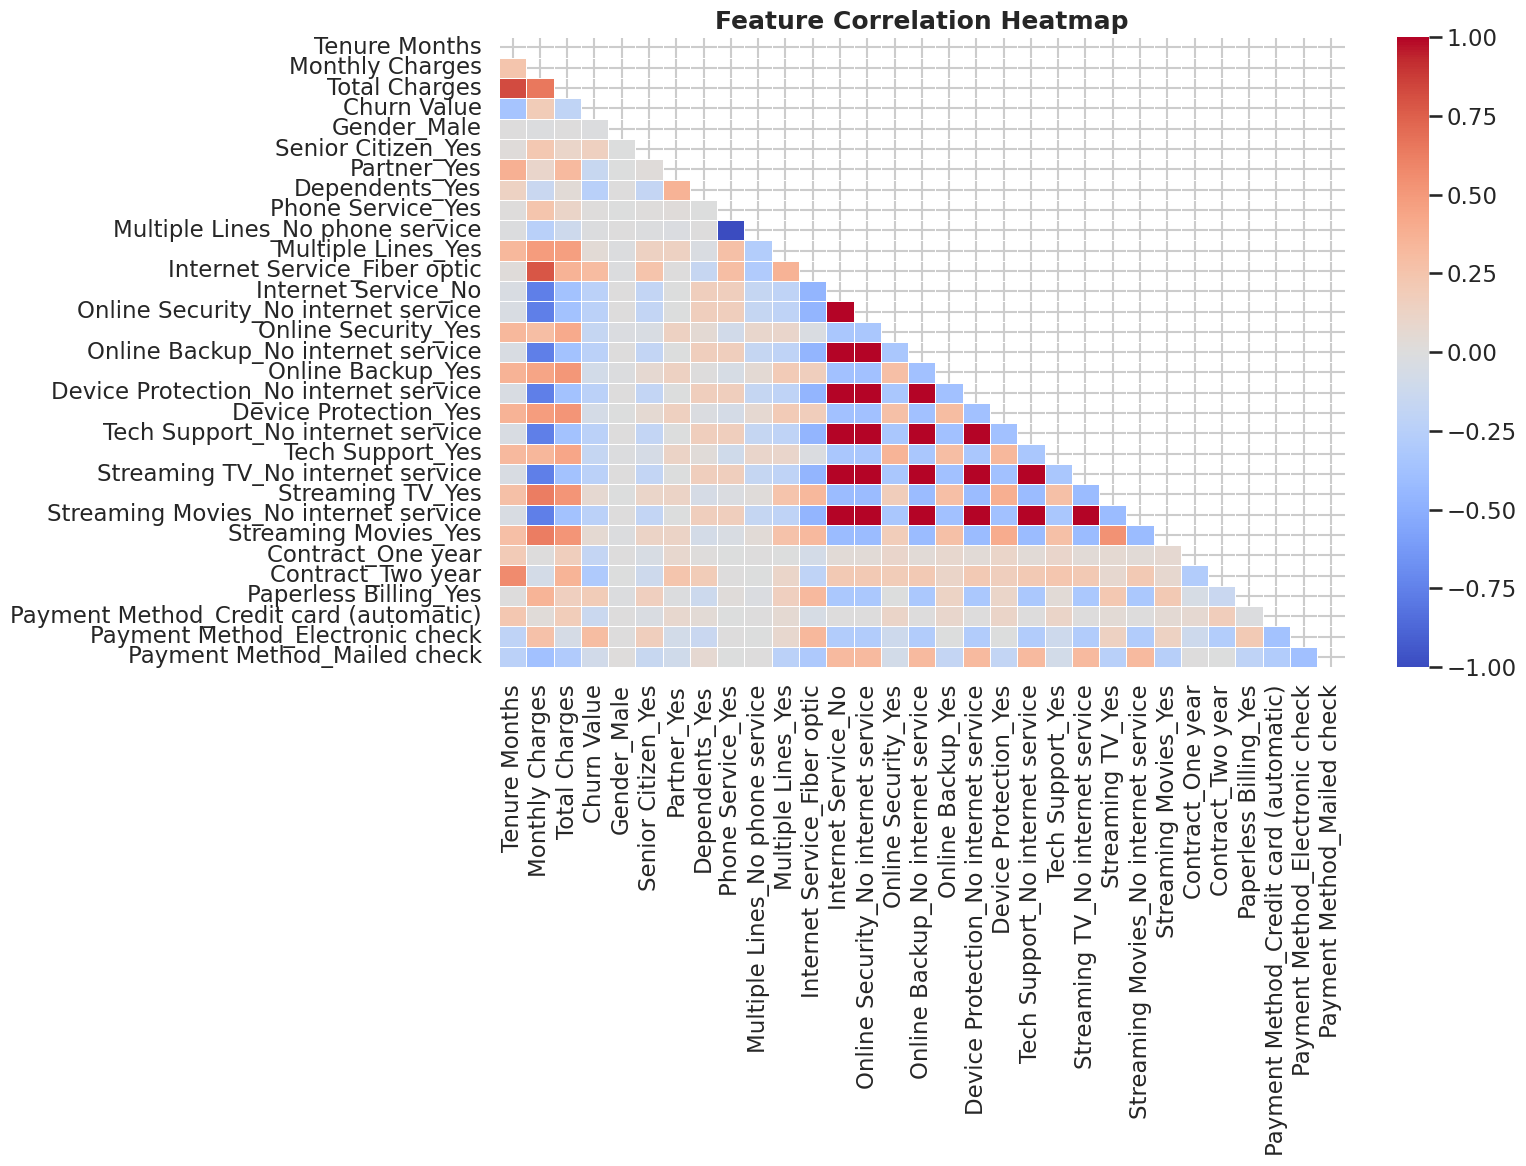

In [ ]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

corr_matrix = df_encoded.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=18, weight="bold")

plt.tight_layout()
plt.show()

The correlation heatmap provides an overview of the relationships among all variables in the dataset. Several features show moderate correlations with churn, particularly tenure, contract type, and internet service attributes. These variables may play an important role in predicting customer churn and will be further examined in the modeling stage

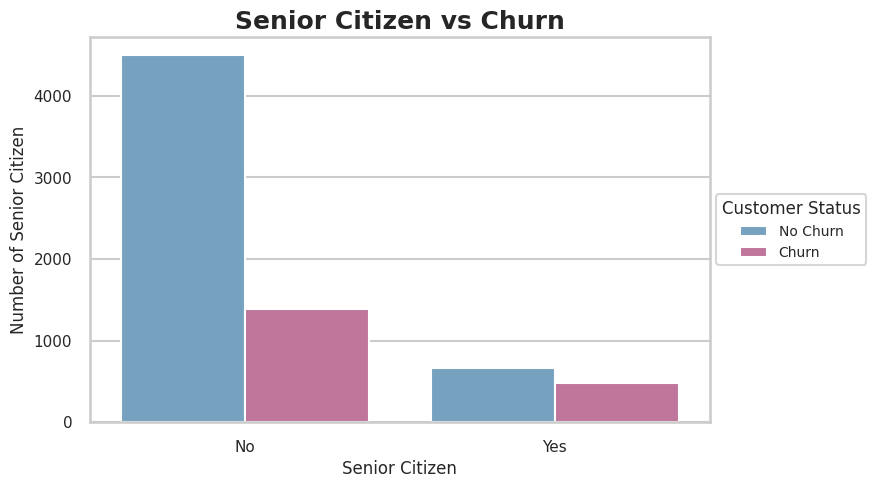

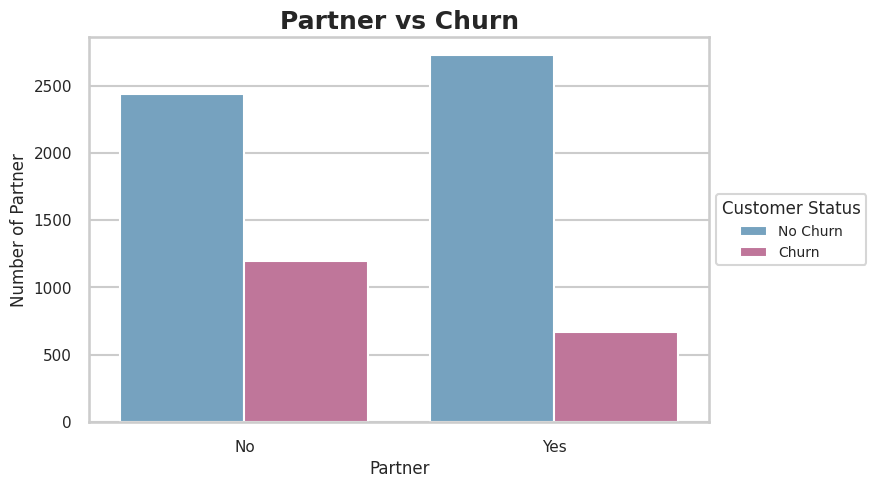

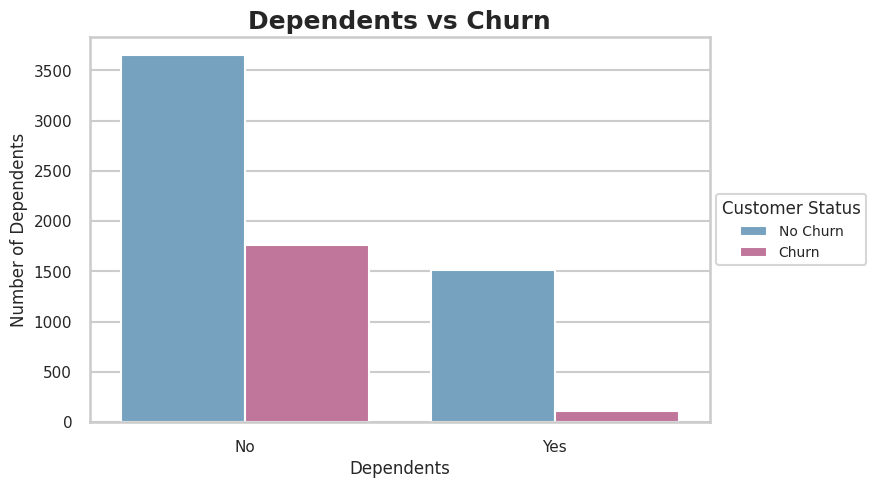

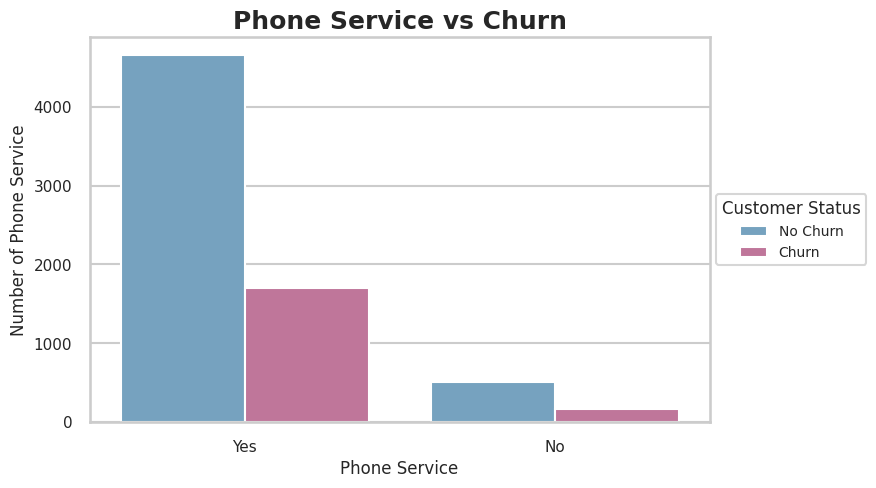

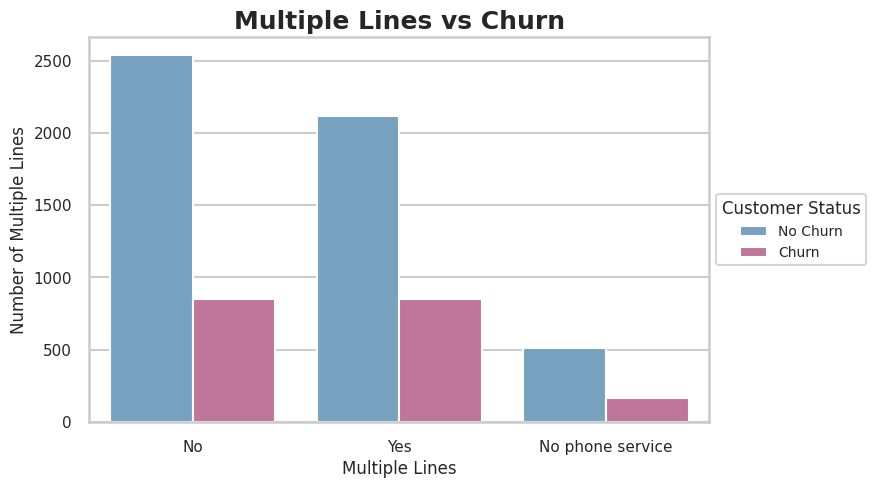

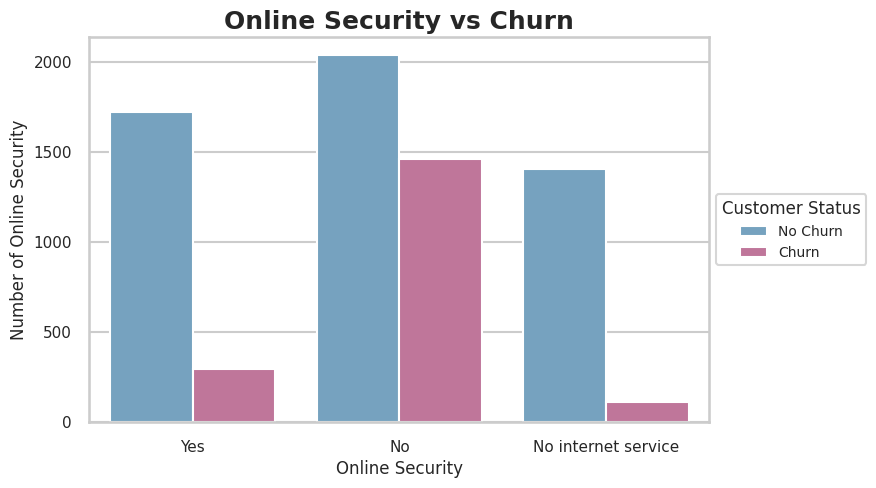

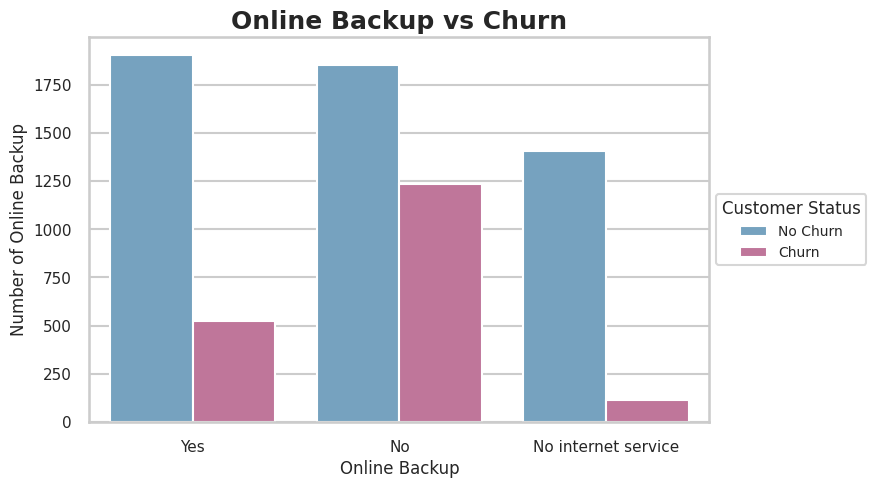

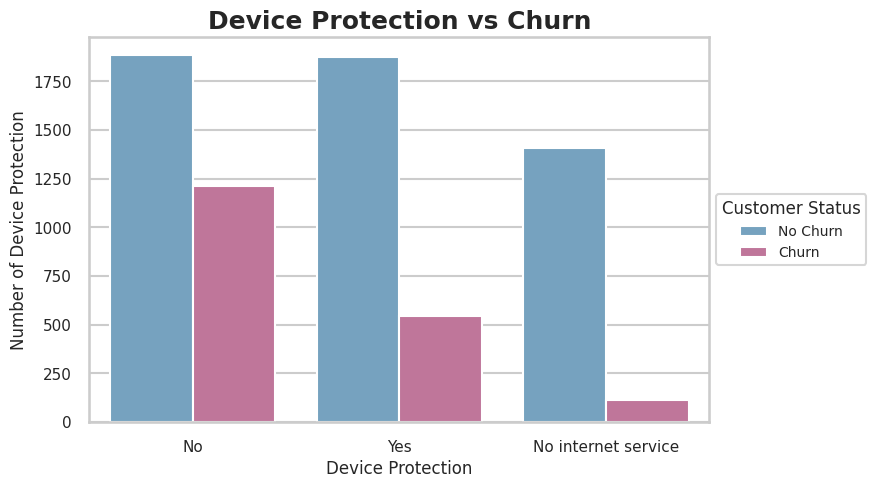

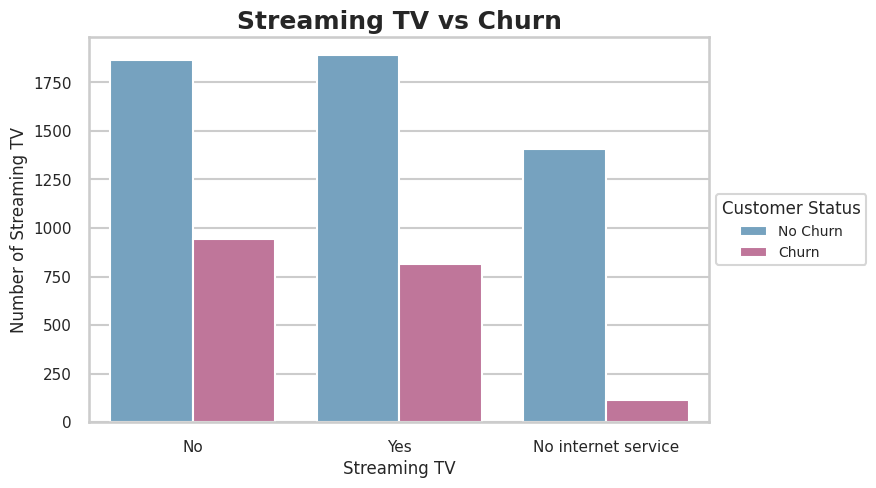

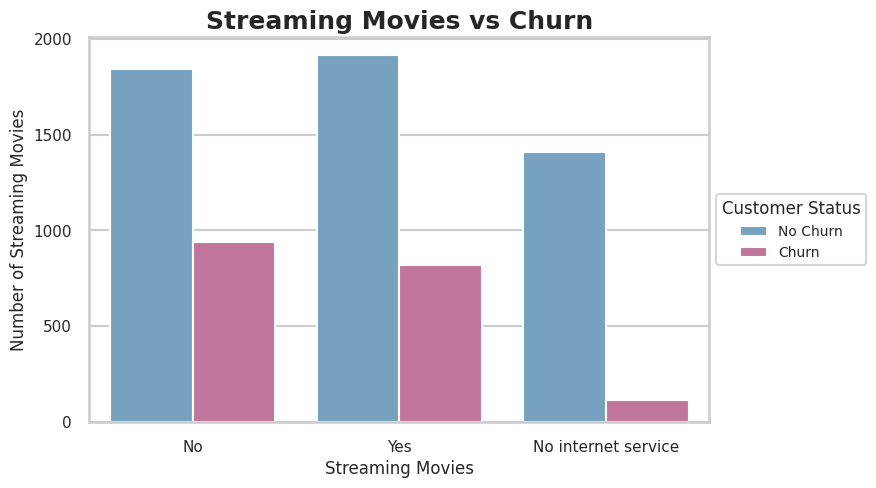

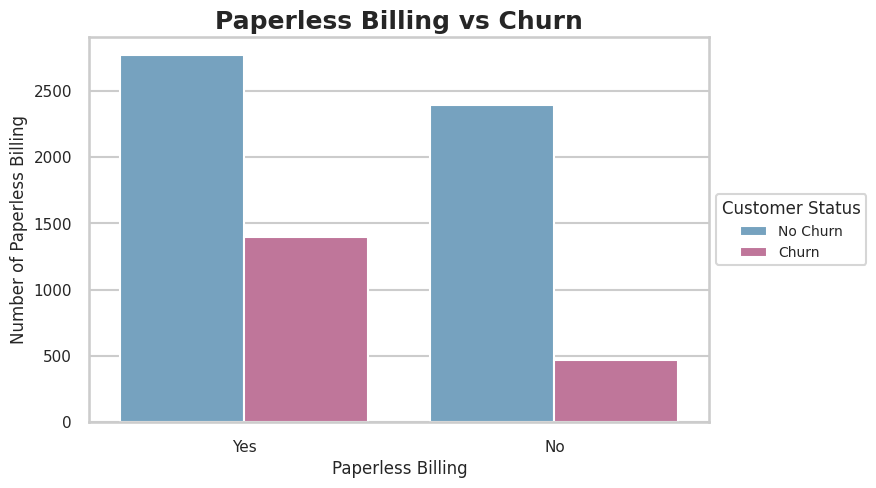

In [ ]:
for col in ["Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing",]:
    sns.countplot(x=col, hue="Churn Value", data=df_clean, palette=["#6aa4cb","#CB6A9A"])
    plt.title(f"{col} vs Churn", weight="bold")
    plt.xlabel(f"{col}", fontsize = 12)
    plt.ylabel(f"Number of {col}", fontsize = 12)

    plt.legend(
        title="Customer Status",
        labels=["No Churn", "Churn"],
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
        title_fontsize=12
    )

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.show()


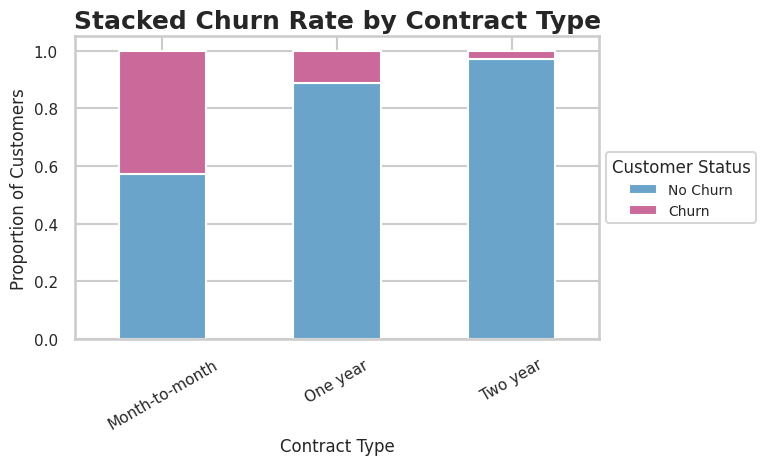

In [ ]:
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn Value"], normalize="index")
ax = contract_churn.plot(
    kind="bar",
    stacked=True,
    color=["#6aa4cb","#CB6A9A"]
)

plt.ylabel("Proportion of Customers", fontsize=12)
plt.xlabel("Contract Type", fontsize=12)
plt.title("Stacked Churn Rate by Contract Type", weight="bold")

plt.xticks(fontsize=11,rotation=30)
plt.yticks(fontsize=11)

plt.legend(
    title="Customer Status",
    labels=["No Churn", "Churn"],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=12
)
plt.tight_layout()
plt.show()

stacked bar charts give us a sense of proportion of churn per category

# Modeling

In [ ]:
# Prepare dataset for modeling

# Use encoded dataset from previous steps
df_model = df_encoded.copy()

# Remove highly correlated variables for all models
drop_cols = [
    "Total Charges",
    "Online Security_No internet service",
    "Online Backup_No internet service",
    "Device Protection_No internet service",
    "Tech Support_No internet service",
    "Streaming TV_No internet service",
    "Streaming Movies_No internet service"
]

df_model = df_model.drop(columns=drop_cols, errors="ignore")

# Define predictors and target
X = df_model.drop("Churn Value", axis=1)
y = df_model["Churn Value"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (7032, 23)
y shape: (7032,)
Number of features: 23


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5625, 23)
Testing set size: (1407, 23)


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
lr = LogisticRegression(max_iter=3000)

# Train model
lr.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 0.8081023454157783

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.65      0.60      0.62       374

    accuracy                           0.81      1407
   macro avg       0.76      0.74      0.75      1407
weighted avg       0.80      0.81      0.81      1407


Confusion Matrix:
[[913 120]
 [150 224]]


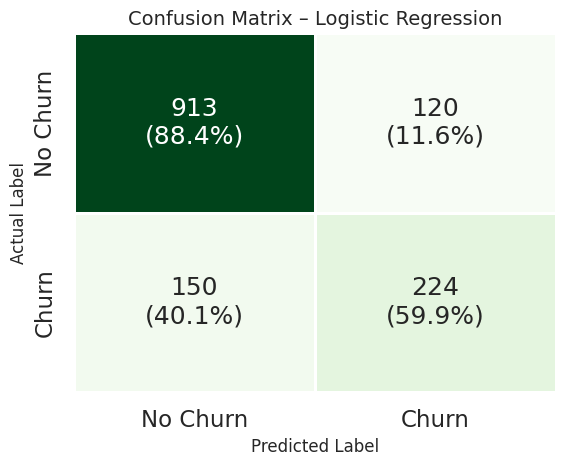

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm[0,0]}\n({cm_percent[0,0]*100:.1f}%)",
     f"{cm[0,1]}\n({cm_percent[0,1]*100:.1f}%)"],

    [f"{cm[1,0]}\n({cm_percent[1,0]*100:.1f}%)",
     f"{cm[1,1]}\n({cm_percent[1,1]*100:.1f}%)"]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    cbar=False,
    linewidths=2,
    linecolor="white"
)

plt.title("Confusion Matrix – Logistic Regression", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.tight_layout()
plt.show()

### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
dt_pred = dt.predict(X_test)

# Accuracy
dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.7818052594171997

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.63      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.78      1407


Confusion Matrix:
[[863 170]
 [137 237]]


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Accuracy
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.7889125799573561

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[914 119]
 [178 196]]


### Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize model
gb = GradientBoostingClassifier(random_state=42)

# Train model
gb.fit(X_train, y_train)

# Predictions
gb_pred = gb.predict(X_test)

# Accuracy
gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Accuracy: 0.798862828713575

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


Confusion Matrix:
[[919 114]
 [169 205]]


### Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
import pandas as pd
from sklearn.metrics import precision_score

from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, precision_score
import pandas as pd

lr_proba = lr.predict_proba(X_test)[:, 1]
dt_proba = dt.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]
gb_proba = gb.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision (Churn=1)": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall (Churn=1)": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, dt_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba)
    ]
})

comparison_df = comparison_df.round(3)

print(comparison_df)

                 Model  Accuracy  Precision (Churn=1)  Recall (Churn=1)  \
0  Logistic Regression     0.808                0.651             0.599   
1        Decision Tree     0.782                0.582             0.634   
2        Random Forest     0.789                0.622             0.524   
3    Gradient Boosting     0.799                0.643             0.548   

   ROC-AUC  
0    0.842  
1    0.829  
2    0.825  
3    0.849  


Logistic Regression AUC: 0.842
Decision Tree AUC: 0.829
Random Forest AUC: 0.825
Gradient Boosting AUC: 0.849


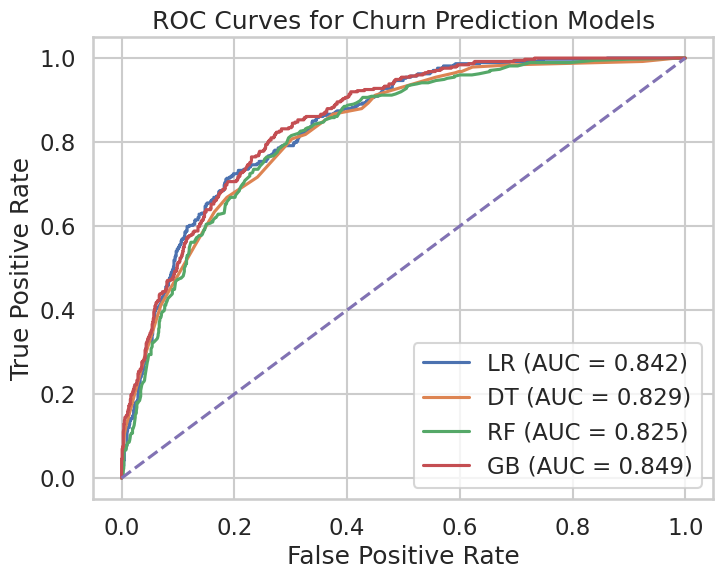

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# predicted probabilities
lr_prob = lr.predict_proba(X_test)[:, 1]
dt_prob = dt.predict_proba(X_test)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
gb_prob = gb.predict_proba(X_test)[:, 1]

# AUC scores
lr_auc = roc_auc_score(y_test, lr_prob)
dt_auc = roc_auc_score(y_test, dt_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
gb_auc = roc_auc_score(y_test, gb_prob)

print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Decision Tree AUC: {dt_auc:.3f}")
print(f"Random Forest AUC: {rf_auc:.3f}")
print(f"Gradient Boosting AUC: {gb_auc:.3f}")

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label=f"LR (AUC = {lr_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"DT (AUC = {dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"RF (AUC = {rf_auc:.3f})")
plt.plot(gb_fpr, gb_tpr, label=f"GB (AUC = {gb_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Churn Prediction Models")
plt.legend()

plt.show()

### Feature Importance

In [ ]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df = coef_df.sort_values("Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient
9,Internet Service_Fiber optic,0.844619
21,Payment Method_Electronic check,0.382241
8,Multiple Lines_Yes,0.351892
15,Streaming TV_Yes,0.319163
7,Multiple Lines_No phone service,0.287980
19,Paperless Billing_Yes,0.276065
16,Streaming Movies_Yes,0.275088
4,Partner_Yes,0.228758
22,Payment Method_Mailed check,0.116359
3,Senior Citizen_Yes,0.069307


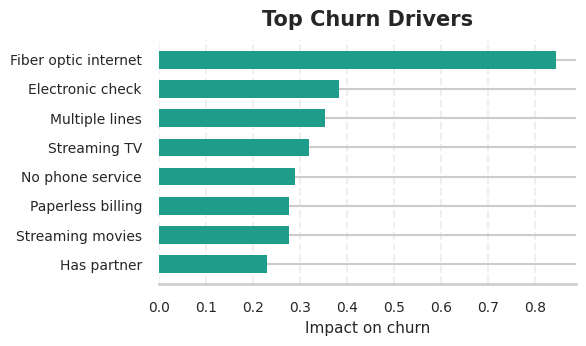

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Select top positive drivers
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(8).copy()

# Rename features for presentation
rename_dict = {
    "Internet Service_Fiber optic": "Fiber optic internet",
    "Payment Method_Electronic check": "Electronic check",
    "Multiple Lines_Yes": "Multiple lines",
    "Streaming TV_Yes": "Streaming TV",
    "Streaming Movies_Yes": "Streaming movies",
    "Paperless Billing_Yes": "Paperless billing",
    "Partner_Yes": "Has partner",
    "Multiple Lines_No phone service": "No phone service"
}

top_positive["Feature"] = top_positive["Feature"].replace(rename_dict)

# Reverse order so the biggest bar is on top after invert_yaxis
top_positive = top_positive.sort_values("Coefficient", ascending=True)

plt.figure(figsize=(6.2, 3.8), facecolor="white")
ax = plt.gca()

# Bar chart
ax.barh(
    top_positive["Feature"],
    top_positive["Coefficient"],
    color="#1f9d8a",
    edgecolor="none",
    height=0.6
)

# Clean style
ax.set_title("Top Churn Drivers", fontsize=15, weight="bold", pad=10)
ax.set_xlabel("Impact on churn", fontsize=11)
ax.set_ylabel("")

# Light gridlines
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Remove extra spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Smaller labels for PPT card layout
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.show()

In [ ]:
df_clean['Churn_Flag'] = df_clean['Churn Value']

def assign_segment(row):
    if row['Tenure Months'] <= 12 and row['Contract'] == 'Month-to-month':
        return 'High Risk: New & Uncommitted'
    elif row['Tenure Months'] > 36 and row['Contract'] != 'Month-to-month':
        return 'Low Risk: Loyal Long-term'
    elif row['Monthly Charges'] > 70 and row['Internet Service'] == 'Fiber optic':
        return 'High Value: Fiber Power User'
    else:
        return 'Mid Tier: Moderate Risk'

df_clean['Segment'] = df_clean.apply(assign_segment, axis=1)

result = df_clean.groupby('Segment').agg(
    Count=('Churn Value', 'count'),
    Churn_Rate=('Churn Value', 'mean'),
    Avg_Monthly=('Monthly Charges', 'mean'),
    Avg_Tenure=('Tenure Months', 'mean')
).round(2)

result['Churn_Rate'] = (result['Churn_Rate'] * 100).round(1).astype(str) + '%'
print(result.sort_values('Count', ascending=False))

                              Count Churn_Rate  Avg_Monthly  Avg_Tenure
Segment                                                                
Low Risk: Loyal Long-term      2343       7.0%        69.18       60.01
High Risk: New & Uncommitted   1994      51.0%        58.22        4.47
Mid Tier: Moderate Risk        1405      11.0%        42.35       24.84
High Value: Fiber Power User   1290      41.0%        91.46       33.77


In [ ]:
monthly_by_churn = df_clean.groupby('Churn Value')['Monthly Charges'].mean()

print("Average Monthly Charges:")
print(f"Stayers (No Churn):  ${monthly_by_churn[0]:.2f}")
print(f"Churners (Churn=1):  ${monthly_by_churn[1]:.2f}")
print(f"Difference: +{((monthly_by_churn[1] - monthly_by_churn[0]) / monthly_by_churn[0] * 100):.1f}%")

Average Monthly Charges:
Stayers (No Churn):  $61.31
Churners (Churn=1):  $74.44
Difference: +21.4%
